# Notebook 6: Visualise Results
Visual analysis of the Re-ID model:
1. **Top-10 ranked results** for sample queries
2. **t-SNE feature visualisation** — before vs after training
3. **Training loss curves** summary
4. **Confusion analysis** — where does the model fail?

In [1]:
import os, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# Redefine model
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.save_for_backward(torch.tensor(lambda_))
        return x.clone()
    @staticmethod
    def backward(ctx, grad_output):
        lambda_, = ctx.saved_tensors
        return -lambda_ * grad_output, None

class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_=1.0): super().__init__(); self.lambda_ = lambda_
    def forward(self, x): return GradientReversalFunction.apply(x, self.lambda_)

class DomainClassifier(nn.Module):
    def __init__(self, in_features=2048, hidden=512):
        super().__init__()
        self.grl = GradientReversalLayer(lambda_=1.0)
        self.classifier = nn.Sequential(
            nn.Linear(in_features, hidden), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(hidden, 2)
        )
    def forward(self, x): return self.classifier(self.grl(x))

class ReIDModel(nn.Module):
    def __init__(self, num_classes, feat_dim=2048):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.bn  = nn.BatchNorm1d(feat_dim)
        self.bn.bias.requires_grad_(False)
        self.id_classifier = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(512, num_classes)
        )
        self.domain_classifier = DomainClassifier(feat_dim, 512)
    def forward(self, x, return_domain=False):
        feat = self.backbone(x)
        feat = self.gap(feat).view(x.size(0), -1)
        feat = self.bn(feat)
        id_logits = self.id_classifier(feat)
        if return_domain:
            return feat, id_logits, self.domain_classifier(feat)
        return feat, id_logits
    def get_features(self, x):
        feat, _ = self.forward(x)
        return F.normalize(feat, p=2, dim=1)

class CCTVTestDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples; self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, pid, cam_id = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, pid, cam_id

TEST_TF = T.Compose([
    T.Resize((256, 128)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Load data and model
with open('dataset_info.pkl', 'rb') as f:
    info = pickle.load(f)
query_samples   = info['query_samples']
gallery_samples = info['gallery_samples']
NUM_CLASSES     = info['num_classes']

checkpoint = torch.load('checkpoints/model_final.pth', map_location=DEVICE)
model = ReIDModel(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print('Model loaded!')

C:\Users\Kathan's Lenovo\AppData\Local\Temp\ipykernel_16488\7631211.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('checkpoints/model_final.pth

Model loaded!


## Visualisation 1: Top-10 Ranked Results for Sample Queries

In [3]:
def extract_features(model, dataloader, device):
    all_feats, all_pids, all_paths = [], [], []
    with torch.no_grad():
        for imgs, pids, _ in tqdm(dataloader, desc='Extracting', leave=False):
            feats = model.get_features(imgs.to(device))
            all_feats.append(feats.cpu())
            all_pids.extend(pids.tolist())
    return torch.cat(all_feats, 0), np.array(all_pids)

q_loader = DataLoader(CCTVTestDataset(query_samples,   TEST_TF), batch_size=64, shuffle=False, num_workers=0)
g_loader = DataLoader(CCTVTestDataset(gallery_samples, TEST_TF), batch_size=64, shuffle=False, num_workers=0)

q_feats, q_pids = extract_features(model, q_loader, DEVICE)
g_feats, g_pids = extract_features(model, g_loader, DEVICE)

dist_matrix = torch.cdist(q_feats, g_feats, p=2).numpy()
print(f'Distance matrix: {dist_matrix.shape}')

Distance matrix: (200, 799)


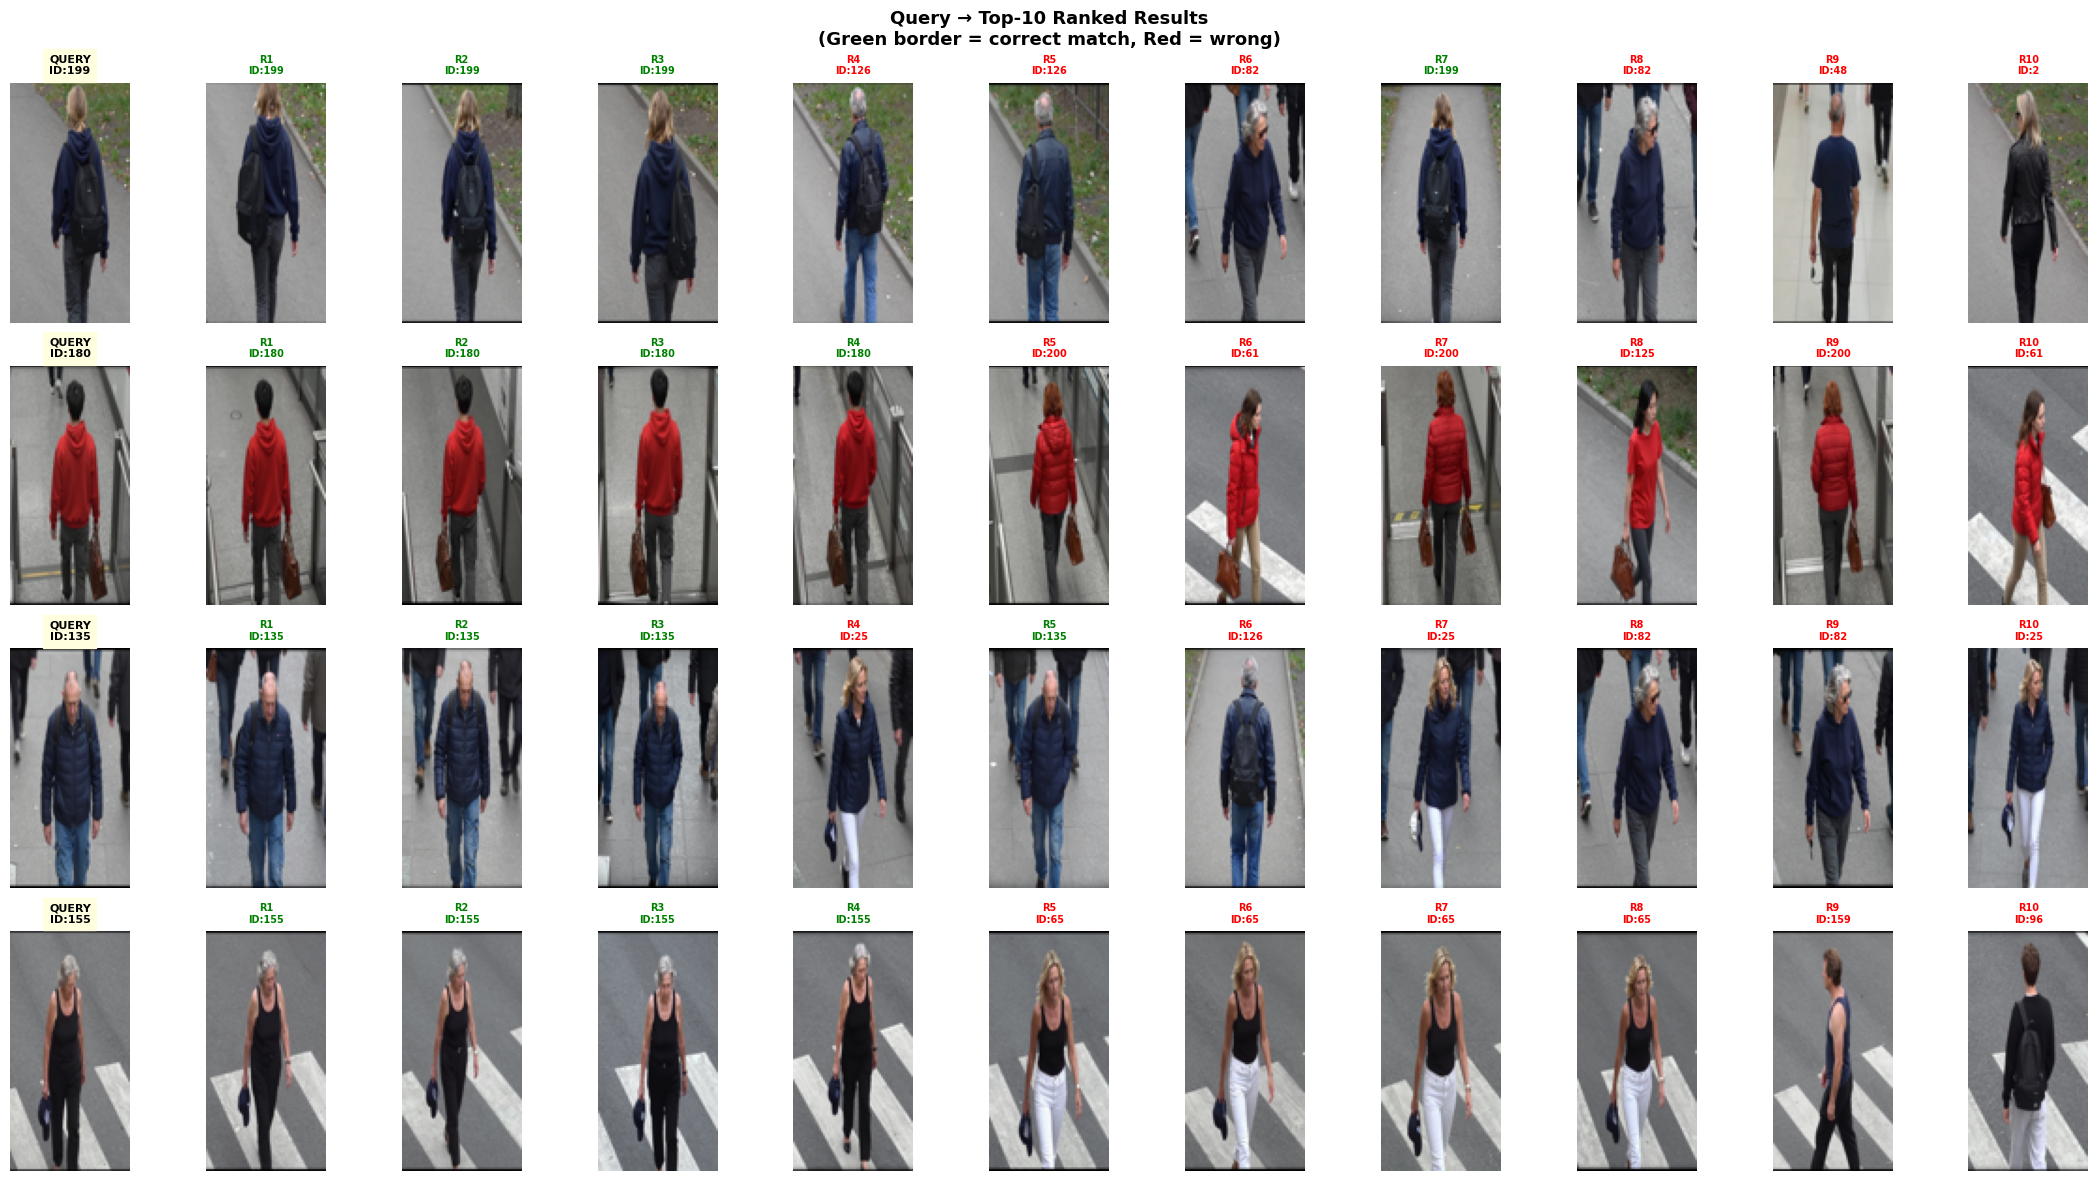

In [4]:
def show_ranked_results(query_samples, gallery_samples, dist_matrix, 
                         q_pids, g_pids, num_queries=4, top_k=10):
    """Show query image and its top-K ranked gallery results."""
    fig, axes = plt.subplots(num_queries, top_k + 1, 
                              figsize=(2*(top_k+1), 3*num_queries))
    fig.suptitle('Query → Top-10 Ranked Results\n(Green border = correct match, Red = wrong)', 
                 fontsize=13, fontweight='bold')

    query_indices = np.random.choice(len(query_samples), num_queries, replace=False)

    for row, q_idx in enumerate(query_indices):
        q_img_path, q_pid, _ = query_samples[q_idx]
        ranked_gallery = np.argsort(dist_matrix[q_idx])[:top_k]

        # Show query image
        ax = axes[row][0]
        q_img = Image.open(q_img_path).convert('RGB').resize((64, 128))
        ax.imshow(q_img)
        ax.set_title(f'QUERY\nID:{q_pid}', fontsize=8, fontweight='bold',
                     color='black', backgroundcolor='lightyellow')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(3)

        # Show top-K gallery results
        for col, g_idx in enumerate(ranked_gallery):
            ax = axes[row][col + 1]
            g_img_path, g_pid, _ = gallery_samples[g_idx]
            g_img = Image.open(g_img_path).convert('RGB').resize((64, 128))
            ax.imshow(g_img)

            is_match = (g_pid == q_pid)
            color = 'green' if is_match else 'red'
            ax.set_title(f'R{col+1}\nID:{g_pid}', fontsize=7,
                         color=color, fontweight='bold')
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)

    plt.tight_layout()
    plt.savefig('ranked_results.png', dpi=150, bbox_inches='tight')
    plt.show()

show_ranked_results(query_samples, gallery_samples, dist_matrix, q_pids, g_pids)

## Visualisation 2: t-SNE Feature Space

Running t-SNE on 80 samples (20 identities)...


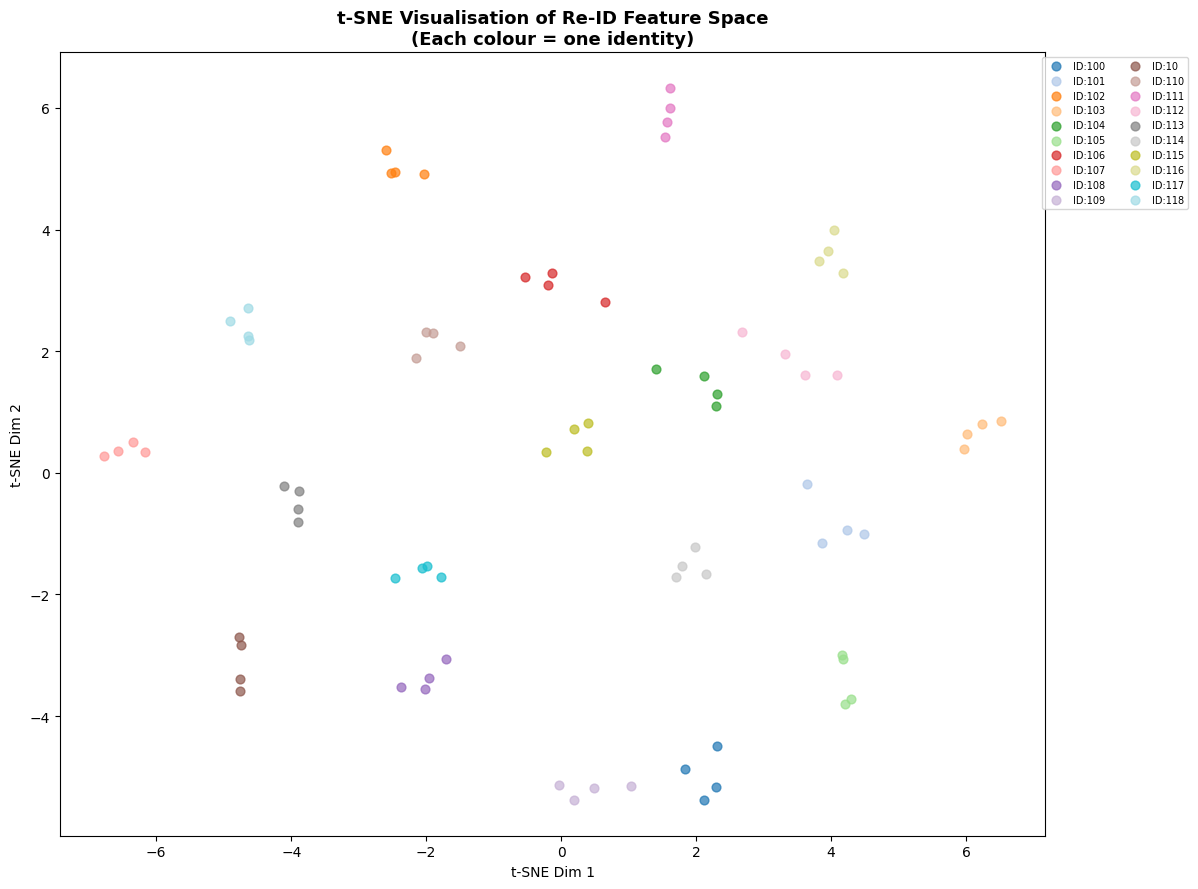

Well-separated clusters = model learned good identity features!


In [5]:
# t-SNE on a subset of gallery features — coloured by identity
# Pick top 20 most frequent identities for clarity
from collections import Counter

pid_counts = Counter(g_pids.tolist())
top_pids   = [p for p, _ in pid_counts.most_common(20)]

mask      = np.isin(g_pids, top_pids)
sub_feats = g_feats[mask].numpy()
sub_pids  = g_pids[mask]

print(f'Running t-SNE on {len(sub_feats)} samples ({len(top_pids)} identities)...')
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
coords = tsne.fit_transform(sub_feats)

# Plot
fig, ax = plt.subplots(figsize=(12, 9))
colors = plt.cm.tab20(np.linspace(0, 1, len(top_pids)))
pid_to_color = {pid: colors[i] for i, pid in enumerate(top_pids)}

for pid in top_pids:
    idx = (sub_pids == pid)
    ax.scatter(coords[idx, 0], coords[idx, 1],
               c=[pid_to_color[pid]], label=f'ID:{pid}',
               alpha=0.7, s=40)

ax.set_title('t-SNE Visualisation of Re-ID Feature Space\n(Each colour = one identity)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dim 1')
ax.set_ylabel('t-SNE Dim 2')
ax.legend(loc='upper right', fontsize=7, ncol=2, 
          bbox_to_anchor=(1.15, 1.0))
plt.tight_layout()
plt.savefig('tsne_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Well-separated clusters = model learned good identity features!')

## Visualisation 3: Training Loss Summary

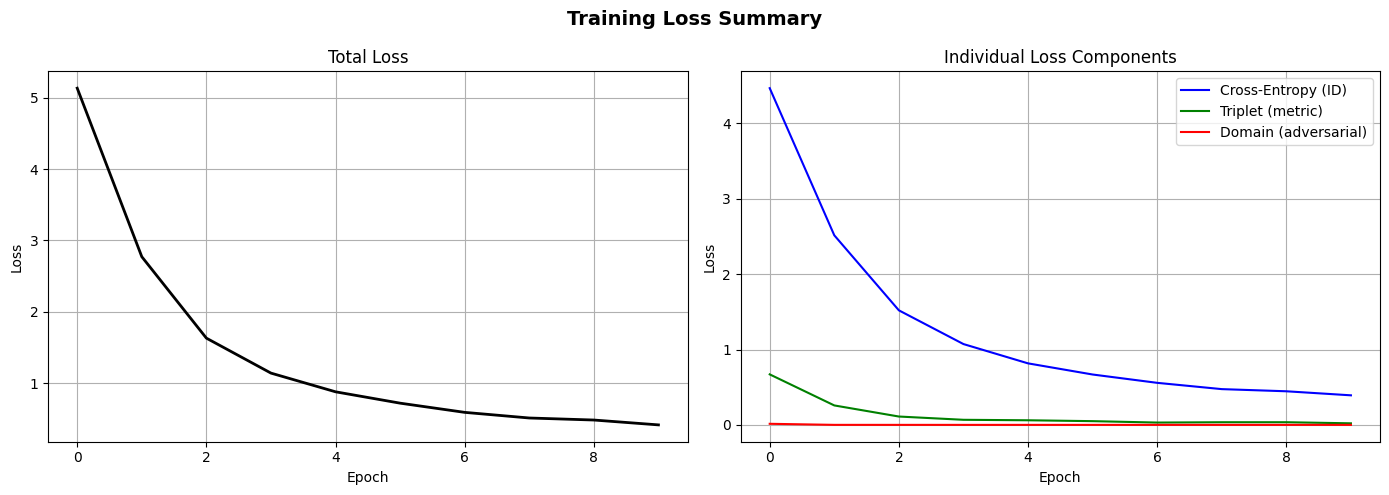

In [6]:
history = checkpoint['history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Loss Summary', fontsize=14, fontweight='bold')

axes[0].plot(history['total'], color='black', linewidth=2)
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(history['ce'],      label='Cross-Entropy (ID)',   color='blue')
axes[1].plot(history['triplet'], label='Triplet (metric)',     color='green')
axes[1].plot(history['domain'],  label='Domain (adversarial)', color='red')
axes[1].set_title('Individual Loss Components')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('loss_summary.png', dpi=150)
plt.show()

## Final Summary

In [7]:
print('='*55)
print('   CROSS-DOMAIN PERSON Re-ID PROJECT SUMMARY')
print('='*55)
print(f'  Source Domain (Train) : PRW Dataset')
print(f'  Target Domain (Test)  : CCTV Pedestrian 1K')
print(f'  Backbone              : ResNet50 (ImageNet pretrained)')
print(f'  Losses                : CE + Triplet + Domain (GRL)')
print(f'  Training Epochs       : {checkpoint["epoch"]}')
print('─'*55)
print(f'  Output files saved:')
print(f'    checkpoints/model_final.pth')
print(f'    training_curves.png')
print(f'    cmc_curve.png')
print(f'    ranked_results.png')
print(f'    tsne_features.png')
print('='*55)
print('\n✅ Project complete!')

   CROSS-DOMAIN PERSON Re-ID PROJECT SUMMARY
  Source Domain (Train) : PRW Dataset
  Target Domain (Test)  : CCTV Pedestrian 1K
  Backbone              : ResNet50 (ImageNet pretrained)
  Losses                : CE + Triplet + Domain (GRL)
  Training Epochs       : 10
───────────────────────────────────────────────────────
  Output files saved:
    checkpoints/model_final.pth
    training_curves.png
    cmc_curve.png
    ranked_results.png
    tsne_features.png

✅ Project complete!
